'''What is Polynomial Regression?

Polynomial Regression is a type of regression used when the relationship between the input (X) and output (Y) is not linear. 

Instead of fitting a straight line like Linear Regression, it fits a curved line to the data.

Linear Regression

It tries to fit a straight line:
y=b0​+b1​x
This works only when data follows a straight-line pattern.

Example:

As study hours increase, marks increase steadily.

Polynomial Regression

When data bends or curves, linear regression fails.

Polynomial Regression adds powers of x:
y=b0​+b1​x+b2​x^2+b3​x^3+⋯+bn​x^n


Understanding Degree
Degree 1
Straight line : yb0 + b1x 


Degree 2 (Quadratic)

Parabola/U-shaped curve ; y= b0 + b1x  + b2x^2 

Degree 3 (Cubic)

More flexible curve :y= b0 + b1x  + b2x^2 + b3x^3


Yes, exactly.
Polynomial Regression creates additional features from the existing feature using powers (degrees)'''


In [30]:
# used when data is non linear , parabolic etc
# we are working on coefeicients mialnly 

In [31]:
# using this regression we are going to predict the previous slary of the employees
# we have a dataset of company , postions and the salaries for all the roles 

## importing the libraries

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## importing the dataset

In [33]:
dataset=pd.read_csv('Position_Salaries.csv')

x = dataset.iloc[:, 1:-1].values # here we have three columns , we are are taking from second to last bfore(-1--> predictio)

y=dataset.iloc[:,-1].values # takes onlylast column

print(x,y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]] [  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


## training the linear regression model on the whole datazset 

In [34]:
from sklearn.linear_model import LinearRegression
lr_obj= LinearRegression()

# train 
# for this time we are taking whole dataset 
lr_obj.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## training the polynomial model on the whole dataset 

In [35]:
# now we are going to multiple linear regression but instead of having different features x1,x2,...xn 
# polynomial is similar to multiple linear regression , but here it adds addinoal features  so we have to implemnt squraes and cubes for the features 

In [36]:
from sklearn.preprocessing import PolynomialFeatures

# the final polynoial outcome will the combination of matrix of powered features and linear regression 


pr_obj = PolynomialFeatures(degree=4)# pass degree value as parameter one by one as 2,3,4....
# here from the dataset wqe have taken only one feature (level) as x1, now we are going to covert the matrix of feature (x1) as x1^2 ...
# so here x1--> first feature and x^2 as second feature

#training
x_poly=pr_obj.fit_transform(x) # tranforming x feature as x^2 feature ,this will cerate a new feature 
# now we have squared featured matrix , now we have to build the linear regreasion and will be integrated in the eqaution of polynomial 
lr2_obj= LinearRegression()
lr2_obj.fit(x_poly,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## visualizing the linear regression reults

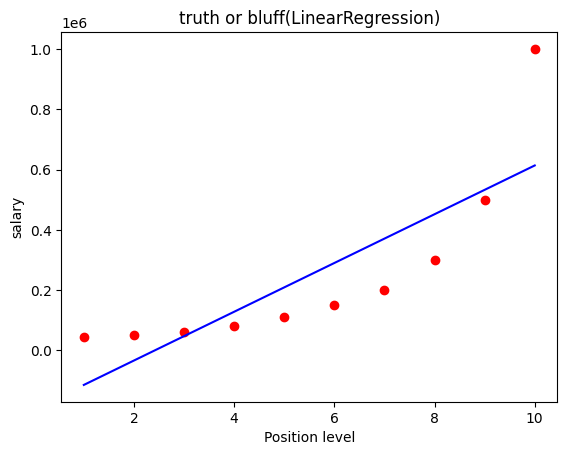

In [37]:
plt.scatter(x,y,color = 'red')
plt.plot(x,lr_obj.predict(x),color= 'blue')# x cordinate and  y-->predicted value code 
plt.title('truth or bluff(LinearRegression)')
plt.xlabel('Position level')
plt.ylabel('salary')
plt.show()


In [38]:
# red dots - actual salary 
# blue line - predicted one 

# here in linear regression  model has not adapted to the dataset 

##  visualizing the polynomial regression reults

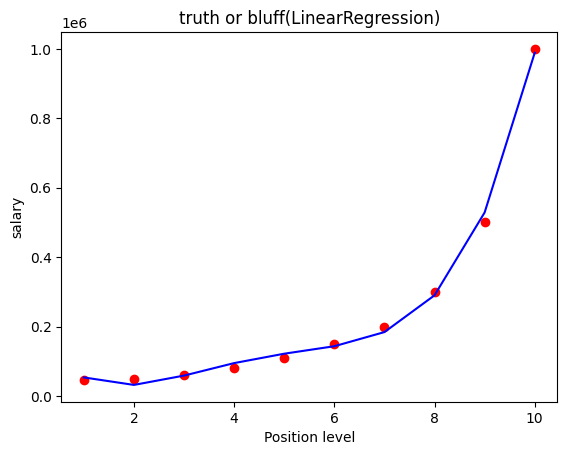

In [39]:
plt.scatter(x,y,color = 'red')

#addind ploynomial (squres)featuers outcome 
plt.plot(x,lr2_obj.predict(pr_obj.fit_transform(x)),color= 'blue')# x cordinate and  y-->predicted value code 
plt.title('truth or bluff(LinearRegression)')
plt.xlabel('Position level')
plt.ylabel('salary')
plt.show()

In [40]:
# changing degree will give more better reult

## visualizing the polynomial regression reults(for higher resolution and smoother curve)

In [41]:
x_grid = np.arange(min(x), max(x), 0.1)
x_grid = x_grid.reshape(len(x_grid), 1)
plt.scatter(x, y, color='red')
plt.plot(x_grid, lr2_obj.predict(pr_obj.fit_transform(x_grid)), color='blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

TypeError: only 0-dimensional arrays can be converted to Python scalars

## Predicting a new result with Linear regression 

In [42]:
lr_obj.predict([[6.5]])# array
# first []--> first dimension --> rows
#second []--> second dimension -->columns



array([330378.78787879])

In [ ]:
# here the predicyion is wrong -->obs  bad prediction

## predicting a new reult with polynomial regression

In [43]:
#here implementing polynoial equation --.>6.5^2, 6.5^^3.....
lr2_obj.predict(pr_obj.fit_transform([[6.5]]))


array([158862.4526515])